# Wizualizacja Algorytmu WOA na Mapce Małopolski

Notebook pokazuje jak wieloryby (agenty) poruszają się po województwie Małopolskim podczas optymalizacji lokalizacji szkoły.

**Co widzisz:**
- Mapa Małopolski z położeniem wielorybów (biblioteka `folium`)
- Animacja ruchu agentów w time-lapie
- Krzywa konwergencji fitness
- Spready populacji w czasie
- Najlepsze rozwiązanie (highlight na mapie)

**Biblioteki:**
- `folium` = mapy interaktywne
- `matplotlib` = wykresy  
- `numpy`, `pandas` = obliczenia
- `shapely` = geometria GIS

In [51]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.animation as animation
from shapely.geometry import Point, Polygon
import folium
from folium import plugins
import warnings
warnings.filterwarnings('ignore')

print("✓ Biblioteki załadowane")
print("  - numpy, pandas, matplotlib (wykresy)")
print("  - folium (mapy interaktywne)")
print("  - shapely (geometria GIS)")

# Imports z projektu
sys.path.insert(0, str(Path.cwd()))
from load_shape import (
    load_voivodeship_geometry, 
    load_gminy_data,
    load_gminy_geometries,
    load_school_rows,
    filter_points_inside_polygon,
    GminaDataAccessor,
    GEOJSON_PATH, 
    POWIATY_PATH, 
    GMINY_READY_PATH,
    SCHOOLS_PATH,
    TARGET_VOIVODESHIP
)
from load_egzaminy import load_egzaminy_data, EgzaminyDataAccessor
from src.woa import WhaleOptimizationAlgorithm

print("✓ Moduły projektu załadowane")

✓ Biblioteki załadowane
  - numpy, pandas, matplotlib (wykresy)
  - folium (mapy interaktywne)
  - shapely (geometria GIS)
✓ Moduły projektu załadowane


In [52]:
print("[1/5] Wczytywanie geometrii...")
geom = load_voivodeship_geometry(GEOJSON_PATH, TARGET_VOIVODESHIP)

print("[2/5] Wczytywanie szkół...")
all_school_rows = load_school_rows(SCHOOLS_PATH)
school_rows_in_region, _ = filter_points_inside_polygon(all_school_rows, geom)

print("[3/5] Wczytywanie danych gmin...")
gminy_data = load_gminy_data(GMINY_READY_PATH)
gminy_geoms = load_gminy_geometries(POWIATY_PATH, geom)

print("[4/5] Tworzenie accessorów...")
gmina_accessor = GminaDataAccessor(gminy_data, gminy_geoms)

DATA_DIR = Path(".") / "DATA"
egzamini_path = DATA_DIR / "E8 - gminy (aktualizacja 07.2025).csv"
egzaminy_data = load_egzaminy_data(egzamini_path)
egzaminy_accessor = EgzaminyDataAccessor(egzaminy_data)

print("[5/5] Dane załadowane\n")

# Centroid województwa (dla mapki)
bounds = geom.bounds
voivodeship_center = [(bounds[1] + bounds[3]) / 2, (bounds[0] + bounds[2]) / 2]
print(f"Centrum województwa: {voivodeship_center}")

[1/5] Wczytywanie geometrii...
[2/5] Wczytywanie szkół...
[3/5] Wczytywanie danych gmin...
[4/5] Tworzenie accessorów...
Dane egzaminow wczytane z kodowaniem: cp1250
[5/5] Dane załadowane

Centrum województwa: [49.84895, 20.25725]


In [53]:
def create_fitness_func(gmina_accessor, egzaminy_accessor, school_rows):
    """Funkcja fitness z dostępem do danych gminy."""
    
    if school_rows:
        school_points = np.array(
            [[s["_x"], s["_y"]] for s in school_rows if "_x" in s and "_y" in s],
            dtype=float,
        )
    else:
        school_points = np.empty((0, 2), dtype=float)
    
    def fitness_func(position: np.ndarray) -> float:
        x, y = position[0], position[1]
        
        gmina_data = gmina_accessor.get_data_for_position(x, y)
        if gmina_data is None or gmina_data.get("data_not_found"):
            return 0.0
        
        if school_points.shape[0] > 0:
            dxy = school_points - np.array([x, y], dtype=float)
            min_dist_to_school = float(np.sqrt(np.min(np.sum(dxy * dxy, axis=1))))
        else:
            min_dist_to_school = 0.0

        suma_u19 = gmina_data.get("suma_U19", 0)
        przystanki = gmina_data.get("przystanki", 0)
        
        # Gładkie skalowanie
        U19_SCALE = 4500.0
        PRZYSTANKI_SCALE = 80.0
        DIST_SCALE = 0.045

        norm_u19 = 1.0 - np.exp(-float(suma_u19) / U19_SCALE)
        norm_przystanki = 1.0 - np.exp(-float(przystanki) / PRZYSTANKI_SCALE)
        norm_dist = 1.0 - np.exp(-float(min_dist_to_school) / DIST_SCALE)
    
        WAGA_DYSTANS = 0.60
        WAGA_DZIECI = 0.20           
        WAGA_KOMUNIKACJA = 0.20     
        
        score = (
            (norm_dist * WAGA_DYSTANS) +
            (norm_u19 * WAGA_DZIECI) + 
            (norm_przystanki * WAGA_KOMUNIKACJA)
        )
        
        return float(score)
    
    return fitness_func

fitness_func = create_fitness_func(gmina_accessor, egzaminy_accessor, school_rows_in_region)
print("✓ Funkcja fitness gotowa")

✓ Funkcja fitness gotowa


In [54]:
# Parametry WOA (zmieniaj tutaj)
WOA_PARAMS = {
    "n_agents": 100,                # liczba wielorybów
    "max_iter": 160,                # liczba iteracji
    "b": 1.0,                      # parametr spirali
    "forced_exploration_prob": 0.25,  # wymuszona eksploracja
    "a_decay_power": 2.0,          # tempo wygaszania parametru a
    "seed": 4,                    # ziarno losowe (powtarzalność)
}

print("Aktualne parametry WOA:")
for key, value in WOA_PARAMS.items():
    print(f"  - {key}: {value}")

Aktualne parametry WOA:
  - n_agents: 100
  - max_iter: 160
  - b: 1.0
  - forced_exploration_prob: 0.25
  - a_decay_power: 2.0
  - seed: 4


In [55]:
class WOAWithHistory(WhaleOptimizationAlgorithm):
    """WOA rozszerzony o logowanie historii pozycji każdego agenta."""
    
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.agent_history = []  # Lista list: [iteracja][agent_idx] = pozycja
        
    def optimize(self, verbose: bool = True) -> tuple[np.ndarray, float]:
        """Rozszerzona optymalizacja z pełną historią."""
        positions = self._init_population()
        scores = self._evaluate_population(positions)
        
        # Zapisz pozycje inicjalizacji
        self.agent_history.append(positions.copy())

        best_idx = int(np.argmax(scores))
        self.best_position = positions[best_idx].copy()
        self.best_score = float(scores[best_idx])

        if verbose:
            print(f"  Inicjalizacja — najlepszy wynik: {self.best_score:.6f}")

        for t in range(self.max_iter):
            progress = t / max(1, self.max_iter - 1)
            a = 2.0 * (1.0 - progress ** self.a_decay_power)

            new_positions = positions.copy()

            for i in range(self.n_agents):
                r1 = self._rng.random()
                r2 = self._rng.random()
                A = 2.0 * a * r1 - a
                C = 2.0 * r2
                p = self._rng.random()
                l = self._rng.uniform(-1.0, 1.0)
                force_explore = self._rng.random() < self.forced_exploration_prob * (1.0 - progress)

                if force_explore:
                    rand_idx = int(self._rng.integers(0, self.n_agents - 1))
                    if rand_idx >= i:
                        rand_idx += 1
                    X_rand = positions[rand_idx]
                    D = np.abs(C * X_rand - positions[i])
                    new_positions[i] = X_rand - A * D
                elif p < 0.5:
                    if abs(A) < 1.0:
                        D = np.abs(C * self.best_position - positions[i])
                        new_positions[i] = self.best_position - A * D
                    else:
                        rand_idx = int(self._rng.integers(0, self.n_agents - 1))
                        if rand_idx >= i:
                            rand_idx += 1
                        X_rand = positions[rand_idx]
                        D = np.abs(C * X_rand - positions[i])
                        new_positions[i] = X_rand - A * D
                else:
                    D_star = np.abs(self.best_position - positions[i])
                    new_positions[i] = (
                        D_star * np.exp(self.b * l) * np.cos(2.0 * np.pi * l)
                        + self.best_position
                    )

            positions = self._clip(new_positions, positions)
            scores = self._evaluate_population(positions)
            
            # Zapisz pozycje tej iteracji
            self.agent_history.append(positions.copy())

            iter_best_idx = int(np.argmax(scores))
            if scores[iter_best_idx] > self.best_score:
                self.best_score = float(scores[iter_best_idx])
                self.best_position = positions[iter_best_idx].copy()

            self.convergence_curve.append(self.best_score)
            self.history.append(positions.copy())

            if verbose:
                iter_best_score = float(scores[iter_best_idx])
                spread = float(np.mean(np.std(positions, axis=0)))
                if (t + 1) % 10 == 0:
                    print(
                        f"  Iteracja {t + 1:>4}/{self.max_iter} | "
                        f"Best: {self.best_score:.6f} | Spread: {spread:.4f}"
                    )

        return self.best_position, self.best_score

# Konfiguracja i uruchomienie WOA
bounds = geom.bounds
lb = [bounds[0], bounds[1]]
ub = [bounds[2], bounds[3]]

print("Uruchamianie WOA z logowaniem historii...\n")
print("Użyte parametry:")
for key, value in WOA_PARAMS.items():
    print(f"  - {key}: {value}")
print()

woa = WOAWithHistory(
    fitness_func=fitness_func,
    lb=lb,
    ub=ub,
    mask_polygon=geom,
    n_agents=WOA_PARAMS["n_agents"],
    max_iter=WOA_PARAMS["max_iter"],
    b=WOA_PARAMS["b"],
    forced_exploration_prob=WOA_PARAMS["forced_exploration_prob"],
    a_decay_power=WOA_PARAMS["a_decay_power"],
    seed=WOA_PARAMS["seed"],
)

best_position, best_score = woa.optimize(verbose=True)

print(f"\n✓ Optymalizacja zakończona")
print(f"Najlepsza pozycja: ({best_position[0]:.4f}, {best_position[1]:.4f})")
print(f"Wynik: {best_score:.6f}")
print(f"Historia agentów: {len(woa.agent_history)} iteracji x {len(woa.agent_history[0])} agentów")

Uruchamianie WOA z logowaniem historii...

Użyte parametry:
  - n_agents: 100
  - max_iter: 160
  - b: 1.0
  - forced_exploration_prob: 0.25
  - a_decay_power: 2.0
  - seed: 4

  Inicjalizacja — najlepszy wynik: 0.736575
  Iteracja   10/160 | Best: 0.843161 | Spread: 0.4160
  Iteracja   20/160 | Best: 0.856645 | Spread: 0.4293
  Iteracja   30/160 | Best: 0.860845 | Spread: 0.4291
  Iteracja   40/160 | Best: 0.862507 | Spread: 0.4307
  Iteracja   50/160 | Best: 0.862713 | Spread: 0.4126
  Iteracja   60/160 | Best: 0.862713 | Spread: 0.4124
  Iteracja   70/160 | Best: 0.862764 | Spread: 0.4009
  Iteracja   80/160 | Best: 0.862764 | Spread: 0.4043
  Iteracja   90/160 | Best: 0.862773 | Spread: 0.4103
  Iteracja  100/160 | Best: 0.862773 | Spread: 0.4198
  Iteracja  110/160 | Best: 0.862773 | Spread: 0.4059
  Iteracja  120/160 | Best: 0.862773 | Spread: 0.4258
  Iteracja  130/160 | Best: 0.862773 | Spread: 0.4221
  Iteracja  140/160 | Best: 0.862897 | Spread: 0.4337
  Iteracja  150/160 | B

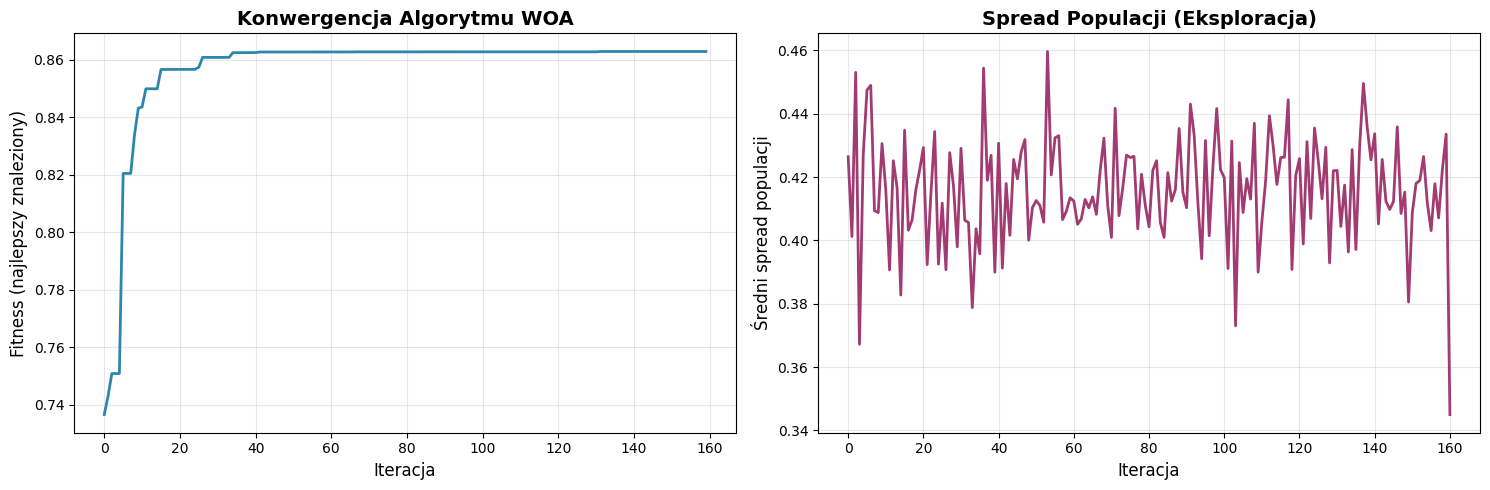


Spread początkowy: 0.4264
Spread końcowy: 0.3450
Średni spread: 0.4160


In [56]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Krzywa konwergencji
axes[0].plot(woa.convergence_curve, linewidth=2, color='#2E86AB')
axes[0].set_xlabel('Iteracja', fontsize=12)
axes[0].set_ylabel('Fitness (najlepszy znaleziony)', fontsize=12)
axes[0].set_title('Konwergencja Algorytmu WOA', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Spread populacji (miara eksploracji)
spreads = []
for positions in woa.agent_history:
    spread = np.mean(np.std(positions, axis=0))
    spreads.append(spread)

axes[1].plot(spreads, linewidth=2, color='#A23B72')
axes[1].set_xlabel('Iteracja', fontsize=12)
axes[1].set_ylabel('Średni spread populacji', fontsize=12)
axes[1].set_title('Spread Populacji (Eksploracja)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nSpread początkowy: {spreads[0]:.4f}")
print(f"Spread końcowy: {spreads[-1]:.4f}")
print(f"Średni spread: {np.mean(spreads):.4f}")

In [57]:
def create_woa_map(iteration_idx, show_trails=False):
    """
    Tworzy mapę folium z pozycjami wielorybów na danej iteracji.

    Parameters:
    - iteration_idx: indeks iteracji (0 = inicjalizacja)
    - show_trails: czy rysować ścieżki z poprzednich iteracji
    """
    from branca.colormap import LinearColormap

    m = folium.Map(
        location=voivodeship_center,
        zoom_start=9,
        tiles='OpenStreetMap'
    )

    # Rysuj granice województwa
    coords_voiv = []
    if hasattr(geom, 'exterior'):
        coords_voiv = list(geom.exterior.coords)
    elif hasattr(geom, 'geoms'):
        for poly in geom.geoms:
            coords_voiv.extend(list(poly.exterior.coords))

    if coords_voiv:
        folium.PolyLine(
            [(lat, lon) for lon, lat in coords_voiv],
            color='black',
            weight=2,
            opacity=0.5,
            popup=f'{TARGET_VOIVODESHIP} (wojewodztwo)'
        ).add_to(m)

    # Pokaż szkoły (drobne punkty)
    for school in school_rows_in_region[:100]:  # Limit dla wydajności
        folium.CircleMarker(
            location=(school["_y"], school["_x"]),
            radius=2,
            color='gray',
            fill=True,
            fillColor='gray',
            fillOpacity=0.3,
            weight=0,
            popup=school.get("nazwa", "Szkola")
        ).add_to(m)

    # Pokaż ścieżki jeśli zaznaczono
    if show_trails and iteration_idx > 0:
        for agent_idx in range(min(5, len(woa.agent_history[0]))):
            trail_points = []
            for iter_idx in range(max(0, iteration_idx - 10), iteration_idx + 1):
                pos = woa.agent_history[iter_idx][agent_idx]
                trail_points.append((pos[1], pos[0]))

            if len(trail_points) > 1:
                folium.PolyLine(
                    trail_points,
                    color='orange',
                    weight=1,
                    opacity=0.4
                ).add_to(m)

    # Pozycje wielorybów i fitness na danej iteracji
    positions = woa.agent_history[iteration_idx]
    agent_scores = np.array([fitness_func(pos) for pos in positions], dtype=float)
    min_score = float(np.min(agent_scores))
    max_score = float(np.max(agent_scores))

    # Skala kolorów: czerwony (słabo) -> żółty -> zielony (dobrze)
    if abs(max_score - min_score) < 1e-12:
        max_score = min_score + 1e-12

    cmap = LinearColormap(
        colors=['#d73027', '#fee08b', '#1a9850'],
        vmin=min_score,
        vmax=max_score,
        caption='Fitness punktu (iteracja)'
    )
    cmap.add_to(m)

    for agent_idx, (pos, score) in enumerate(zip(positions, agent_scores)):
        point_color = cmap(float(score))
        folium.CircleMarker(
            location=(pos[1], pos[0]),
            radius=5,
            color=point_color,
            fill=True,
            fillColor=point_color,
            fillOpacity=0.85,
            weight=1,
            popup=(
                f'Wieloryb {agent_idx}<br>'
                f'Iteracja: {iteration_idx}<br>'
                f'Fitness: {float(score):.6f}<br>'
                f'X: {pos[0]:.5f}, Y: {pos[1]:.5f}'
            )
        ).add_to(m)

    # Najlepszy punkt w tej iteracji
    best_idx_in_iteration = int(np.argmax(agent_scores))
    best_pos_in_iteration = positions[best_idx_in_iteration]
    best_score_in_iteration = agent_scores[best_idx_in_iteration]
    folium.Marker(
        location=(best_pos_in_iteration[1], best_pos_in_iteration[0]),
        popup=f'<b>Najlepszy punkt w iteracji {iteration_idx}</b><br>Fitness: {best_score_in_iteration:.6f}',
        icon=folium.Icon(color='red', icon='star', prefix='fa')
    ).add_to(m)

    # Panel informacyjny
    title_html = f'''
    <div style="position: fixed;
     top: 10px; left: 50px; width: 360px; height: 88px;
     background-color: white; border:2px solid grey; z-index:9999;
     font-size: 14px; padding: 10px;">
     <b>WOA - Iteracja {iteration_idx}</b><br>
     Best global: {woa.best_score:.6f}<br>
     Fitness iteracji: min {min_score:.6f} | max {max_score:.6f}<br>
     Spread: {spreads[iteration_idx]:.4f}
    </div>
    '''
    m.get_root().html.add_child(folium.Element(title_html))

    return m

# Pokaż mapę dla inicjalizacji
print("Tworzę mapy dla wybranych iteracji...\n")
map_init = create_woa_map(0)
print("Iteracja 0 (inicjalizacja):")
map_init

Tworzę mapy dla wybranych iteracji...

Iteracja 0 (inicjalizacja):


In [58]:
# Pokaż mapę dla połowy algorytmu
mid_iter = len(woa.agent_history) // 2
print(f"\nIteracja {mid_iter} (połowa algorytmu):")
map_mid = create_woa_map(mid_iter, show_trails=True)
map_mid


Iteracja 80 (połowa algorytmu):


In [59]:
# Pokaż mapę dla ostatniej iteracji
final_iter = len(woa.agent_history) - 1
print(f"\nIteracja {final_iter} (koniec algorytmu):")
map_final = create_woa_map(final_iter, show_trails=True)
map_final


Iteracja 160 (koniec algorytmu):


In [60]:
import matplotlib.animation as animation
from IPython.display import HTML

# Stwórz animację (statyczna wizualizacja - matplotlib)
fig, ax = plt.subplots(figsize=(12, 10))

# Konwersja bounds do współrzędnych map
bounds = geom.bounds
map_extent = [bounds[0], bounds[2], bounds[1], bounds[3]]

def init_plot():
    ax.clear()
    return ax,

def animate_agents(iteration):
    ax.clear()
    
    # Rysuj granice województwa
    if hasattr(geom, 'exterior'):
        xs, ys = zip(*geom.exterior.coords)
        ax.plot(xs, ys, 'k-', linewidth=1, alpha=0.3)
    
    # Pokaż szkoły
    if len(school_rows_in_region) > 0:
        school_array = np.array([[s["_x"], s["_y"]] for s in school_rows_in_region if "_x" in s])
        ax.scatter(school_array[:, 0], school_array[:, 1], c='gray', s=5, alpha=0.2, label='Szkoły')
    
    # Wieloryby na bieżącej iteracji
    positions = woa.agent_history[iteration]
    ax.scatter(positions[:, 0], positions[:, 1], c='#2E86AB', s=50, alpha=0.7, label=f'Wieloryby (iter {iteration})')
    
    # Najlepszy punkt
    ax.scatter(woa.best_position[0], woa.best_position[1], c='red', s=200, marker='*', 
               edgecolor='darkred', linewidth=2, label='Najlepszy punkt', zorder=10)
    
    ax.set_xlim(bounds[0] - 0.1, bounds[2] + 0.1)
    ax.set_ylim(bounds[1] - 0.1, bounds[3] + 0.1)
    ax.set_xlabel('Długość geograficzna')
    ax.set_ylabel('Szerokość geograficzna')
    ax.set_title(f'WOA - Iteracja {iteration} | Fitness: {woa.best_score:.6f} | Spread: {spreads[iteration]:.4f}')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.2)
    ax.set_aspect('equal')

# Animuj co 5 iteracji dla szybszego odtwarzania
step = max(1, len(woa.agent_history) // 20)  # Pokaż około 20 klatek
anim = animation.FuncAnimation(
    fig, animate_agents,
    frames=range(0, len(woa.agent_history), step),
    init_func=init_plot,
    interval=200,  # 200ms między klatkami
    repeat=True,
    blit=False
)

plt.tight_layout()
plt.close()
anim.save('woa_animation.gif', writer='pillow', fps=5)
print(f"\nAnimation frames: {len(range(0, len(woa.agent_history), step))}")
print("Animacja nie jest wyświetlana w Jupyter w tym formacie.")
print("Aby zobaczyć animację, zapisz ją jako GIF:")
print("anim.save('woa_animation.gif', writer='pillow', fps=5)")


Animation frames: 21
Animacja nie jest wyświetlana w Jupyter w tym formacie.
Aby zobaczyć animację, zapisz ją jako GIF:
anim.save('woa_animation.gif', writer='pillow', fps=5)
